# Análise Exploratória dos Dados — Dados Brutos

Exploração inicial do dataset de **5.8 milhões de voos domésticos dos EUA em 2015**, proveniente do US Department of Transportation.

Objetivo: entender a estrutura dos dados, identificar padrões de valores ausentes, e explorar distribuições e relações antes da limpeza.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
sns.set_style('whitegrid')

In [20]:
flights = pd.read_csv("../data/flights.csv", low_memory=False)
airports = pd.read_csv("../data/airports.csv")
airlines = pd.read_csv("../data/airlines.csv")

# Join airlines (by AIRLINE code)
flights = flights.merge(airlines, left_on="AIRLINE", right_on="IATA_CODE", how="left") \
                 .drop(columns="IATA_CODE") \
                 .rename(columns={"AIRLINE_y": "AIRLINE_NAME", "AIRLINE_x": "AIRLINE"})

# Join airports for ORIGIN
flights = flights.merge(airports, left_on="ORIGIN_AIRPORT", right_on="IATA_CODE", how="left") \
                 .drop(columns="IATA_CODE") \
                 .rename(columns={
                     "AIRPORT": "ORIGIN_AIRPORT_NAME",
                     "CITY": "ORIGIN_CITY",
                     "STATE": "ORIGIN_STATE",
                     "LATITUDE": "ORIGIN_LAT",
                     "LONGITUDE": "ORIGIN_LON"
                 }).drop(columns=["COUNTRY"])

# Join airports for DESTINATION
flights = flights.merge(airports, left_on="DESTINATION_AIRPORT", right_on="IATA_CODE", how="left") \
                 .drop(columns="IATA_CODE") \
                 .rename(columns={
                     "AIRPORT": "DEST_AIRPORT_NAME",
                     "CITY": "DEST_CITY",
                     "STATE": "DEST_STATE",
                     "LATITUDE": "DEST_LAT",
                     "LONGITUDE": "DEST_LON"
                 }).drop(columns=["COUNTRY"])

print(f"Shape após joins: {flights.shape}")

print(flights.head(5))

Shape após joins: (5819079, 42)
   YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE  FLIGHT_NUMBER TAIL_NUMBER  \
0  2015      1    1            4      AS             98      N407AS   
1  2015      1    1            4      AA           2336      N3KUAA   
2  2015      1    1            4      US            840      N171US   
3  2015      1    1            4      AA            258      N3HYAA   
4  2015      1    1            4      AS            135      N527AS   

  ORIGIN_AIRPORT DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  DEPARTURE_TIME  \
0            ANC                 SEA                    5          2354.0   
1            LAX                 PBI                   10             2.0   
2            SFO                 CLT                   20            18.0   
3            LAX                 MIA                   20            15.0   
4            SEA                 ANC                   25            24.0   

   DEPARTURE_DELAY  TAXI_OUT  WHEELS_OFF  SCHEDULED_TIME  ELAPSED_TIME  \
0   

## Fontes de Dados

O dataset é composto por 3 arquivos CSV:
- **flights.csv** — 5.819.079 registros de voos com horários, atrasos e cancelamentos
- **airports.csv** — metadados dos aeroportos (nome, cidade, estado, coordenadas)
- **airlines.csv** — códigos e nomes das companhias aéreas

Os joins (left) adicionam 10 colunas de contexto geográfico. Cerca de **8,3% dos aeroportos** usam códigos FAA numéricos que não possuem correspondência na tabela IATA, gerando NaN nas colunas de join.

In [21]:
flights.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 42 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       str    
 8   DESTINATION_AIRPORT  str    
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24  CANCELLED

In [22]:
missing = flights.isnull().sum()
missing_pct = (missing / len(flights) * 100).round(2)
missing_df = pd.DataFrame({'Ausentes': missing, '%': missing_pct}).query('Ausentes > 0').sort_values('%', ascending=False)
print(f"Colunas com valores ausentes: {len(missing_df)} de {len(flights.columns)}\n")
missing_df

Colunas com valores ausentes: 28 de 42



,Ausentes,%
CANCELLATION_REASON,5729195,98.46
AIRLINE_DELAY,4755640,81.72
AIR_SYSTEM_DELAY,4755640,81.72
SECURITY_DELAY,4755640,81.72
WEATHER_DELAY,4755640,81.72
LATE_AIRCRAFT_DELAY,4755640,81.72
ORIGIN_LAT,490770,8.43
ORIGIN_LON,490770,8.43
DEST_LON,490775,8.43
DEST_LAT,490775,8.43


## Estratégia de Valores Ausentes

A análise revela **4 padrões distintos** de dados faltantes:

| Padrão | Colunas | % NaN | Causa |
|--------|---------|-------|-------|
| Causas de atraso | AIR_SYSTEM_DELAY, SECURITY_DELAY, etc. | ~82% | **By design** — só preenchido para voos atrasados |
| Cancelamento | CANCELLATION_REASON | ~98,5% | **By design** — só preenchido para voos cancelados |
| Dados operacionais | DEPARTURE_DELAY, ARRIVAL_DELAY, etc. | ~1,5% | **Realmente faltante** — voos desviados ou falha de registro |
| Colunas de join | ORIGIN_AIRPORT_NAME, ORIGIN_CITY, etc. | ~8,3% | Aeroportos com código FAA numérico sem match IATA |


In [23]:
flights.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,ORIGIN_LAT,ORIGIN_LON,DEST_LAT,DEST_LON
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,5.819073e+06,5.714008e+06,5.714008e+06,5.819079e+06,5.726566e+06,5.726566e+06,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,5.328309e+06,5.328309e+06,5.328304e+06,5.328304e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,1.416859e+02,1.370062e+02,1.135116e+02,8.223565e+02,1.471469e+03,7.434971e+00,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00,3.663806e+01,-9.549123e+01,3.663795e+01,-9.549102e+01
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,7.521058e+01,7.421107e+01,7.223082e+01,6.077843e+02,5.221879e+02,5.638548e+00,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01,5.999338e+00,1.815637e+01,5.999285e+00,1.815616e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,1.800000e+01,1.400000e+01,7.000000e+00,2.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.348345e+01,-1.766460e+02,1.348345e+01,-1.766460e+02
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,8.500000e+01,8.200000e+01,6.000000e+01,3.730000e+02,1.054000e+03,4.000000e+00,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.289595e+01,-1.119778e+02,3.289595e+01,-1.119778e+02
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,1.230000e+02,1.180000e+02,9.400000e+01,6.470000e+02,1.509000e+03,6.000000e+00,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00,3.736186e+01,-9.025803e+01,3.736186e+01,-9.025803e+01
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,1.730000e+02,1.680000e+02,1.440000e+02,1.062000e+03,1.911000e+03,9.000000e+00,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00,4.078839e+01,-8.168786e+01,4.078839e+01,-8.168786e+01
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,7.180000e+02,7.660000e+02,6.900000e+02,4.983000e+03,2.400000e+03,2.480000e+02,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03,7.128545e+01,-6.479856e+01,7.128545e+01,-6.479856e+01


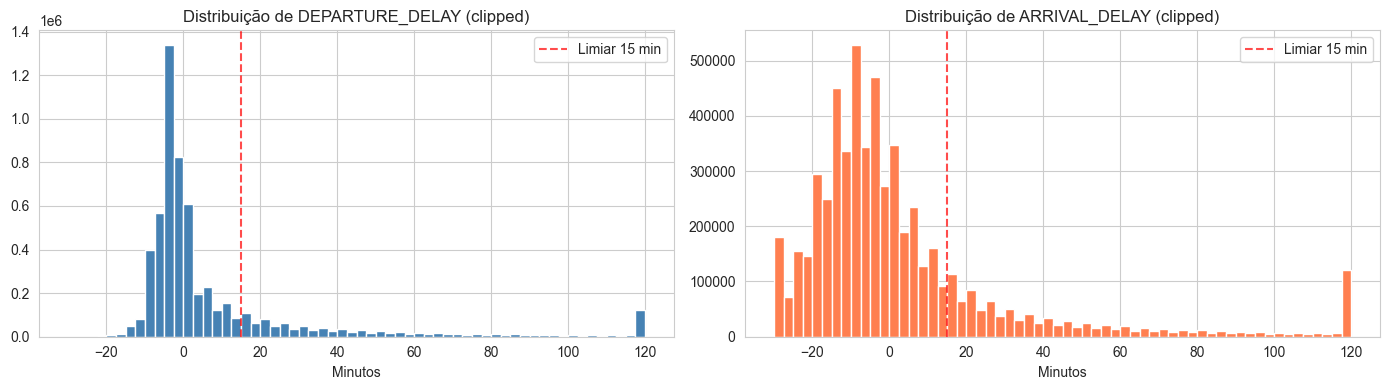

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

flights['DEPARTURE_DELAY'].dropna().clip(-30, 120).hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição de DEPARTURE_DELAY (clipped)')
axes[0].set_xlabel('Minutos')
axes[0].axvline(x=15, color='red', linestyle='--', alpha=0.7, label='Limiar 15 min')
axes[0].legend()

flights['ARRIVAL_DELAY'].dropna().clip(-30, 120).hist(bins=60, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Distribuição de ARRIVAL_DELAY (clipped)')
axes[1].set_xlabel('Minutos')
axes[1].axvline(x=15, color='red', linestyle='--', alpha=0.7, label='Limiar 15 min')
axes[1].legend()

plt.tight_layout()
plt.show()

Taxa de cancelamento: 1.54% (89,884 voos)



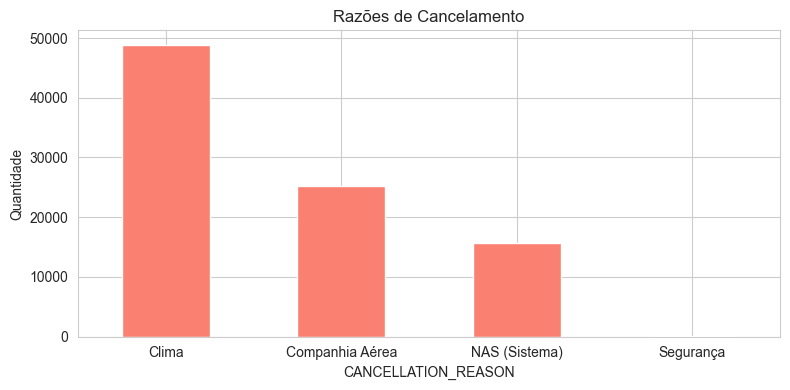

CANCELLATION_REASON
Clima              48851
Companhia Aérea    25262
NAS (Sistema)      15749
Segurança             22
Name: count, dtype: int64


In [25]:
cancel_rate = flights['CANCELLED'].mean() * 100
print(f"Taxa de cancelamento: {cancel_rate:.2f}% ({flights['CANCELLED'].sum():,} voos)\n")

cancel_map = {'A': 'Companhia Aérea', 'B': 'Clima', 'C': 'NAS (Sistema)', 'D': 'Segurança'}
cancelled_flights = flights[flights['CANCELLED'] == 1]
reason_counts = cancelled_flights['CANCELLATION_REASON'].map(cancel_map).value_counts()

reason_counts.plot(kind='bar', figsize=(8, 4), title='Razões de Cancelamento', color='salmon', edgecolor='white')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(reason_counts)

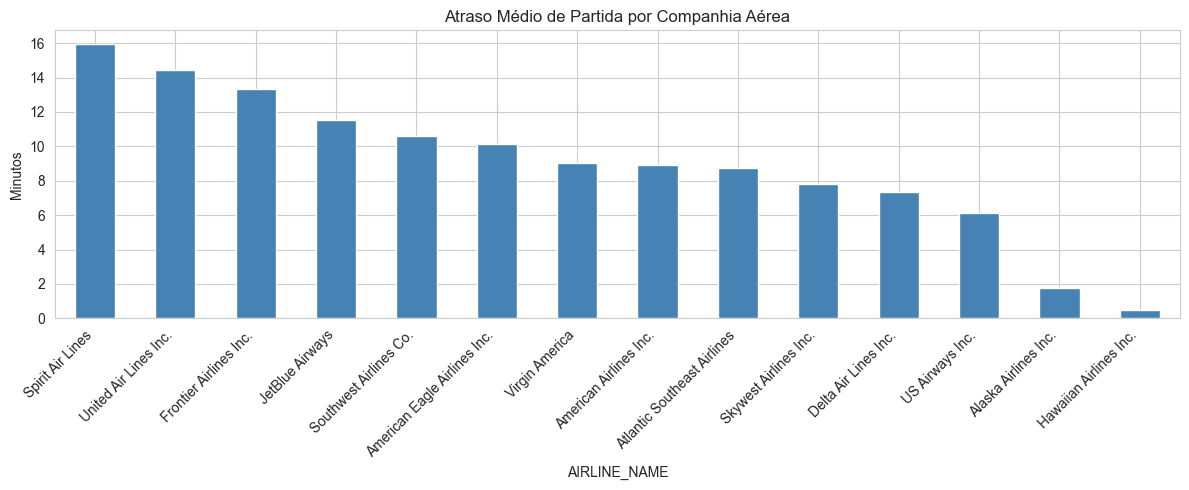

In [26]:
avg_delay_airline = flights.groupby('AIRLINE_NAME')['DEPARTURE_DELAY'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
avg_delay_airline.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Atraso Médio de Partida por Companhia Aérea')
plt.ylabel('Minutos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

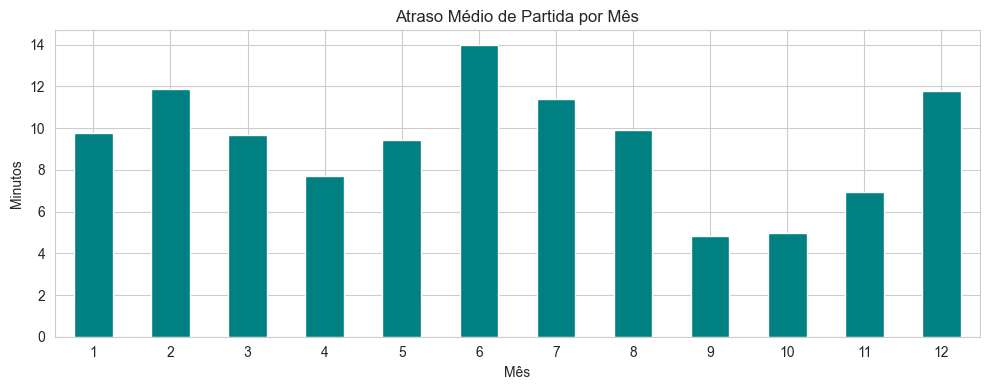

In [27]:
month_delay = flights.groupby('MONTH')['DEPARTURE_DELAY'].mean()

plt.figure(figsize=(10, 4))
month_delay.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Atraso Médio de Partida por Mês')
plt.ylabel('Minutos')
plt.xlabel('Mês')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

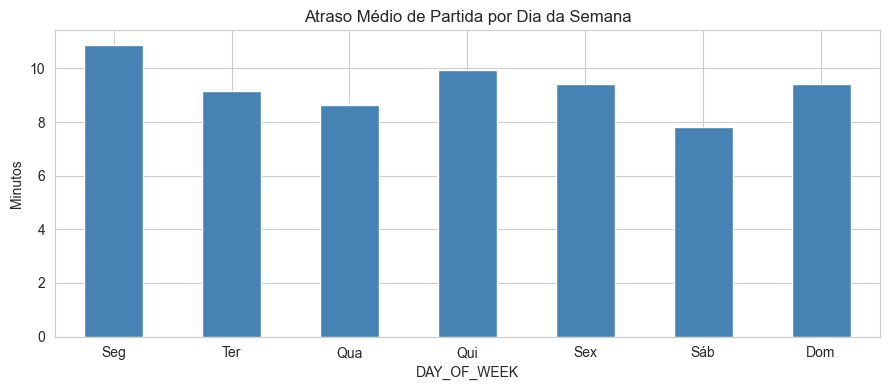

In [28]:
day_labels = {1: 'Seg', 2: 'Ter', 3: 'Qua', 4: 'Qui', 5: 'Sex', 6: 'Sáb', 7: 'Dom'}
dow_delay = flights.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].mean()
dow_delay.index = dow_delay.index.map(day_labels)

plt.figure(figsize=(9, 4))
dow_delay.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Atraso Médio de Partida por Dia da Semana')
plt.ylabel('Minutos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

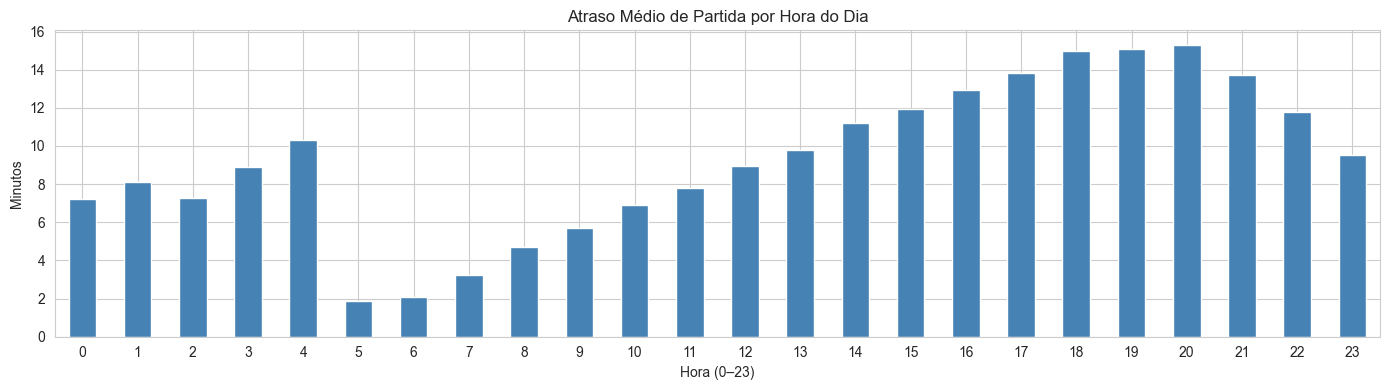

In [29]:
hour_delay = flights.groupby(flights['SCHEDULED_DEPARTURE'] // 100)['DEPARTURE_DELAY'].mean()

plt.figure(figsize=(14, 4))
hour_delay.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Atraso Médio de Partida por Hora do Dia')
plt.xlabel('Hora (0–23)')
plt.ylabel('Minutos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

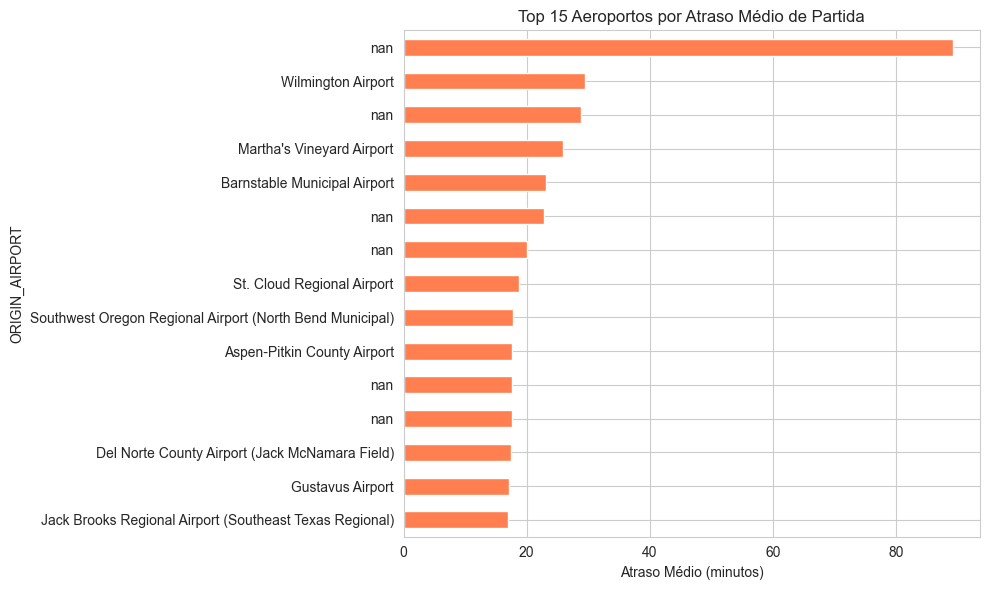

In [30]:
airport_delay = (flights.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY']
                 .mean()
                 .sort_values(ascending=False)
                 .head(15))

code_to_name = flights.drop_duplicates('ORIGIN_AIRPORT').set_index('ORIGIN_AIRPORT')['ORIGIN_AIRPORT_NAME']
airport_delay.index = airport_delay.index.map(lambda x: code_to_name.get(x, x))

plt.figure(figsize=(10, 6))
airport_delay.plot(kind='barh', color='coral', edgecolor='white')
plt.title('Top 15 Aeroportos por Atraso Médio de Partida')
plt.xlabel('Atraso Médio (minutos)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

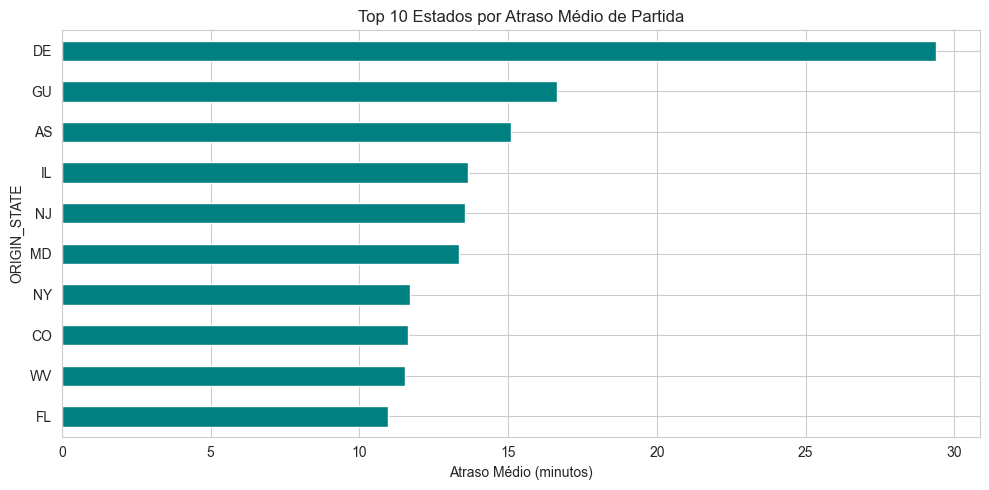

In [31]:
state_delay = (flights[flights['ORIGIN_STATE'].notna()]
               .groupby('ORIGIN_STATE')['DEPARTURE_DELAY']
               .mean()
               .sort_values(ascending=False)
               .head(10))

plt.figure(figsize=(10, 5))
state_delay.plot(kind='barh', color='teal', edgecolor='white')
plt.title('Top 10 Estados por Atraso Médio de Partida')
plt.xlabel('Atraso Médio (minutos)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Mapa de Calor — Atraso Médio por Aeroporto de Origem

Mapa geográfico com bolhas proporcionais ao volume de voos e coloridas pelo atraso médio de partida. Filtrado para aeroportos com no mínimo 100 voos no ano.

In [33]:
import plotly.express as px

# Atraso médio por aeroporto de origem
airport_stats = (flights.groupby('ORIGIN_AIRPORT')
                 .agg(avg_delay=('DEPARTURE_DELAY', 'mean'),
                      n_flights=('DEPARTURE_DELAY', 'count'))
                 .reset_index())
airport_stats = airport_stats[airport_stats['n_flights'] >= 100]
airport_stats = airport_stats.merge(coords, left_on='ORIGIN_AIRPORT', right_index=True)

fig = px.scatter_geo(
    airport_stats,
    lat='LATITUDE', lon='LONGITUDE',
    color='avg_delay',
    size='n_flights',
    hover_name='ORIGIN_AIRPORT',
    hover_data={'avg_delay': ':.1f', 'n_flights': True},
    color_continuous_scale='YlOrRd',
    scope='usa',
    title='Atraso Médio de Partida por Aeroporto de Origem (mín. 100 voos)',
    labels={'avg_delay': 'Atraso médio (min)', 'n_flights': 'Nº voos'}
)
fig.update_layout(height=500)
fig.show()

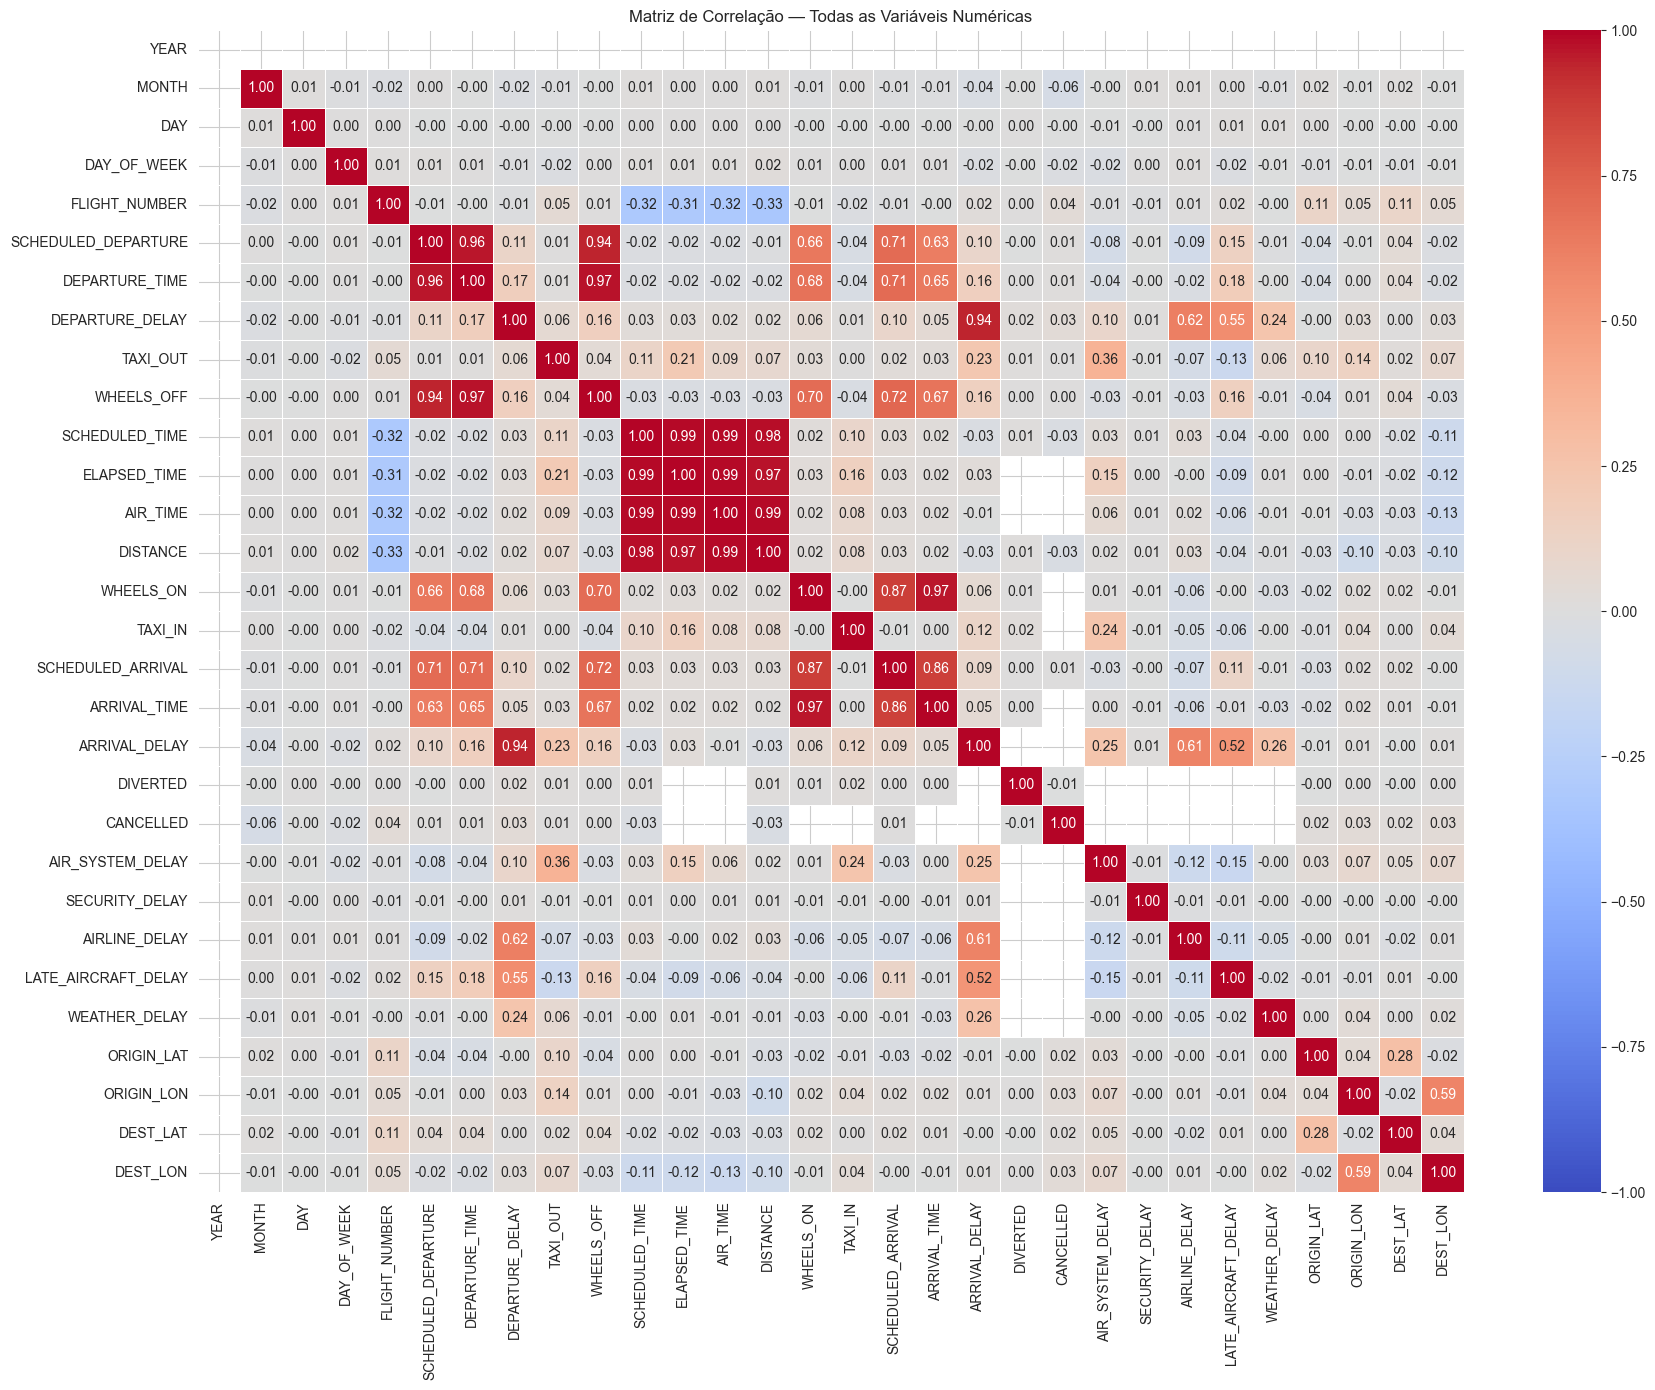

In [34]:
corr = flights.select_dtypes(include='number').corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação — Todas as Variáveis Numéricas')
plt.tight_layout()
plt.show()

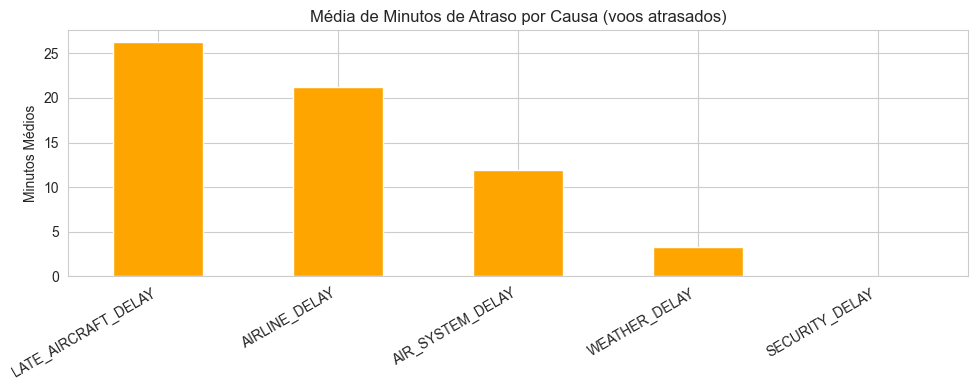

In [35]:
delay_cause_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
                    'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
delayed = flights[flights['DEPARTURE_DELAY'] > 0]
cause_means = delayed[delay_cause_cols].mean().sort_values(ascending=False)

cause_means.plot(kind='bar', figsize=(10, 4),
                 title='Média de Minutos de Atraso por Causa (voos atrasados)',
                 color='orange', edgecolor='white')
plt.ylabel('Minutos Médios')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [36]:
extreme = (flights['DEPARTURE_DELAY'] > 300).sum()
max_delay = flights['DEPARTURE_DELAY'].max()
print(f"Voos com atraso de partida > 300 min: {extreme:,}  ({extreme/len(flights)*100:.2f}%)")
print(f"Atraso máximo de partida: {max_delay:.0f} min (~{max_delay/60:.1f} horas)")

Voos com atraso de partida > 300 min: 11,275  (0.19%)
Atraso máximo de partida: 1988 min (~33.1 horas)


## Conclusões da Exploração

### Padrões identificados
- **Sazonalidade**: Verão (Jun–Ago) e feriados de inverno (Dez–Jan) apresentam atrasos elevados; outono é o melhor período
- **Padrão diário**: Atrasos se acumulam ao longo do dia — voos matutinos são mais pontuais, voos noturnos sofrem mais
- **Dia da semana**: Quinta e sexta-feira tendem a ter os maiores atrasos; sábado é geralmente o melhor dia
- **Companhias**: Variação significativa.
- **Outliers**: <1% dos voos têm atrasos extremos (>300 min), sugerindo disrupções sistêmicas ocasionais
- **Imbalance**: ~82% dos voos são pontuais (atraso ≤ 15 min)

### Decisões de limpeza necessárias
→ Ver notebook **`ETL.ipynb`** para o pipeline completo de preparação dos dados.